Near Adiabatic Return to Ground State
===============================

The Matt Chow (MC) gate style takes advantage of a surprisingly consistent return to ground state. We want to understand why this happens. We know that if we go too fast, the MC gate does not work, and if we goo very slow we are in the adiabatic regime where we expect this to happen. We will explore the "near-adiabatic" regime.

First some code that is originally from the [./pulses_test.ipynb](./pulses_test.ipynb) file:

Want to be able to represent a spin $\tfrac{1}{2}$ system so we can test the time evolution of different pulses. Our Hamiltonian can be controlled by a laser. A laser can be controlled by the intensity, frequency, and phase. While not exactly the same, these can be mapped to three parameters in our Hamiltonian:
$$
\text{intensity} \mapsto \Omega(t) \\
\text{frequency} \mapsto \Delta(t) \\
\text{phase} \mapsto \phi(t) 
$$
which appear in the Hamiltonian as follows:
$$
\hat{H} = \frac{-\Delta(t)}{2}\hat{1} 
    - \frac{-\Delta(t)}{2}\hat{\sigma}_z 
    + \frac{\Omega(t)}{2}
        (
            \cos{\phi(t)}\hat{\sigma}_x +
            \sin{\phi(t)}\hat{\sigma}_y
        )
    = \frac{-\Delta(t)}{2}\hat{1} + \frac{1}{2}\tilde{\vec{\Omega}}(t) \cdot \hat{\vec{\sigma}}
$$

$\phi$ is just the phase ends up being the axial angle on the Bloch sphere.

In [1]:
using QuantumOptics
using LinearAlgebra
using Interpolations
using CairoMakie

computational = SpinBasis(1//2)

I = identityoperator(computational)
σx = sigmax(computational)
σy = sigmay(computational)
σz = sigmaz(computational)
σ_vec = [σx, σy, σz];

down = spindown(computational)
up = spinup(computational)


function twoLevelSysFromParameters(Ψ₀::StateVector, Δ::Function, Ω::Function, ϕ::Function, T::Real; number_of_reported_times::Int = 100)
    
    H(t, ignored) = Ω(t)*σx/2 - Δ(t)*I/2 - Δ(t)*σz/2 

    tspan = range(0, T, number_of_reported_times)
    tout, psi_t = timeevolution.schroedinger_dynamic(tspan, down, H)
    return tout, psi_t, (t -> H(t, 0))
end 

"""
Integrate the Hamiltonian for an initial state Ψ₀.
"""
function twoLevelSysFromBlochAngles(Ψ₀::StateVector, Ω_eff_mag::Function, θ::Function, ϕ::Function, T::Real; number_of_reported_times = 100)
    Δ(t) = -cos(θ(t))*Ω_eff_mag(t)
    Ω(t) = sin(θ(t))*Ω_eff_mag(t)

    # Ω_vec(t) = [Ω(t)*cos(ϕ(t)), Ω(t)*sin(ϕ(t)), -Δ(t)]
    # H(t, ignored) = Ω(t)*σx/2 - Δ(t)*I/2 - Δ(t)*σz/2 

    return twoLevelSysFromParameters(Ψ₀, Δ, Ω, ϕ, T, number_of_reported_times=number_of_reported_times)
end


function mattChow(T::Real, Ω_scaling=1)
    fudge_factor = 1.65 # this was not part of the original gate but is needed for the simulation to match the experimental data
    Ω_points = fudge_factor*2π .* [0.0, 0.412, 0.825, 1.237, 1.485, 1.485, 1.237, 0.825, 0.412, 0.0]
    Δ_points = 2π .* [4.08, 3.06, 2.04, 1.02, 0.408, 0.408, 1.02, 2.04, 3.06, 4.08]

    ts = range(0, T, length(Ω_points))
    Δ(t) = cubic_spline_interpolation(ts, Δ_points)(t) # this could also be `Ω = cubic_spline_interpolation(ts, Ω_points)` ¯\_(ツ)_/¯
    Ω(t) = cubic_spline_interpolation(ts, Ω_points)(t) * Ω_scaling
    ϕ(t) = 0

    (tout, psi_t, H) = twoLevelSysFromParameters(down, Δ, Ω, ϕ, T)
    return (tout, psi_t, H), (Δ, Ω, ϕ) # returns a lot of stuff but they are all useful
end
;

Now if we look at the MC gate over time we see the efficiency of returning to the ground state:

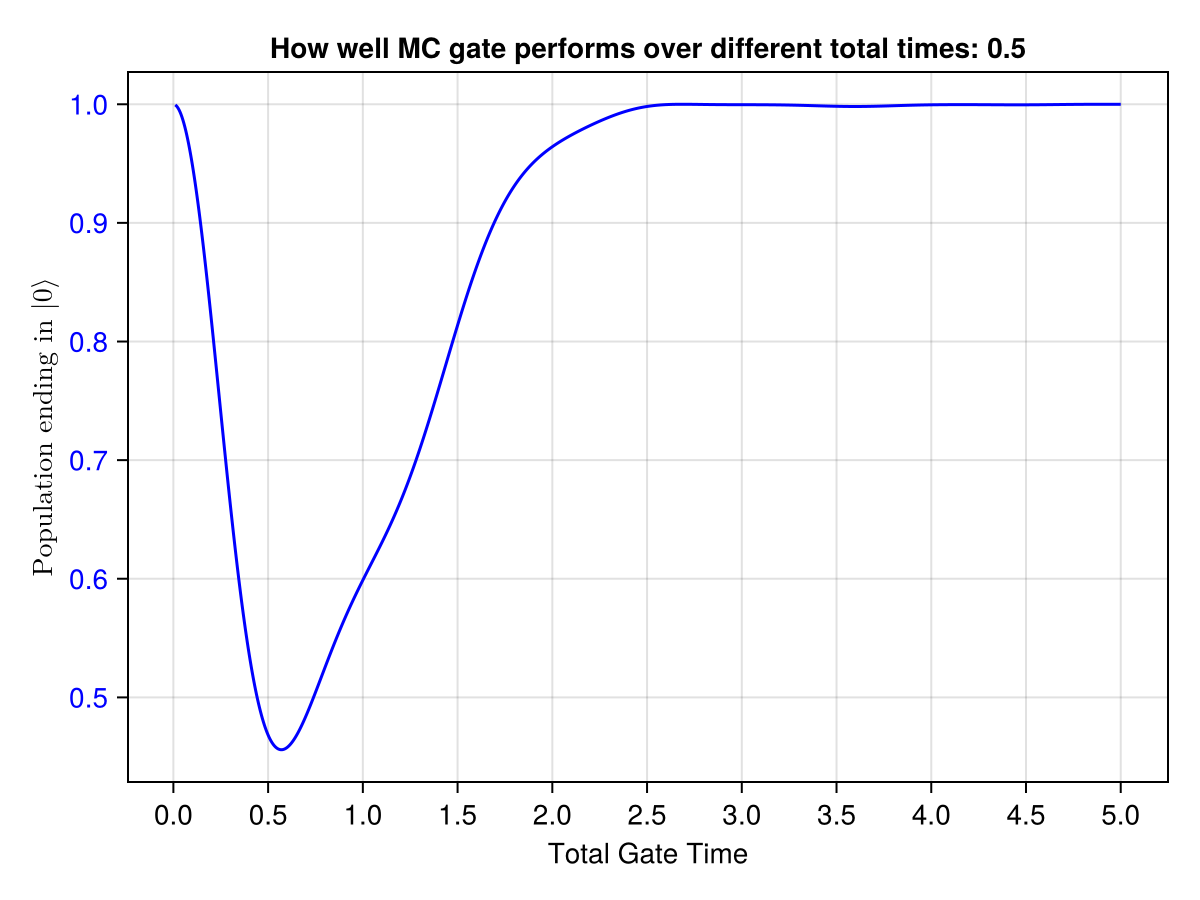

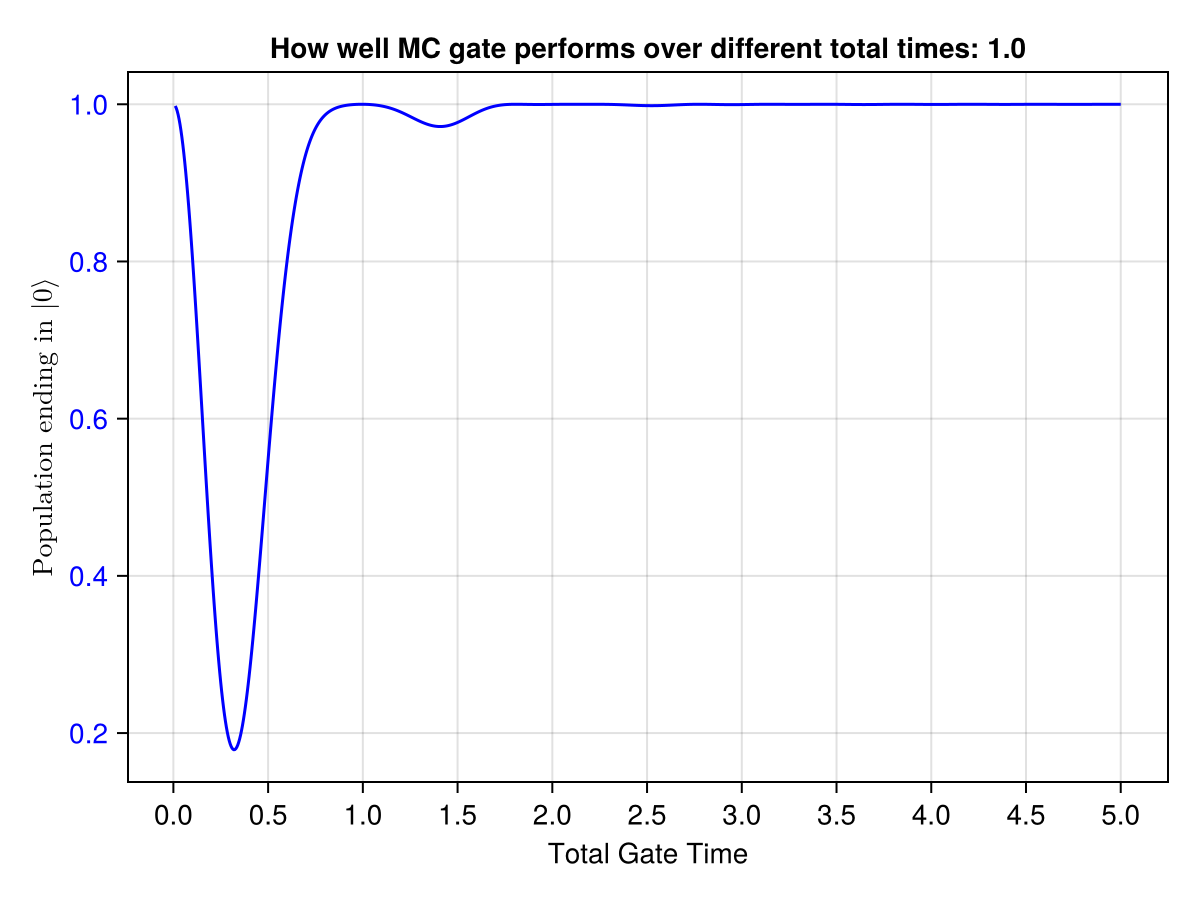

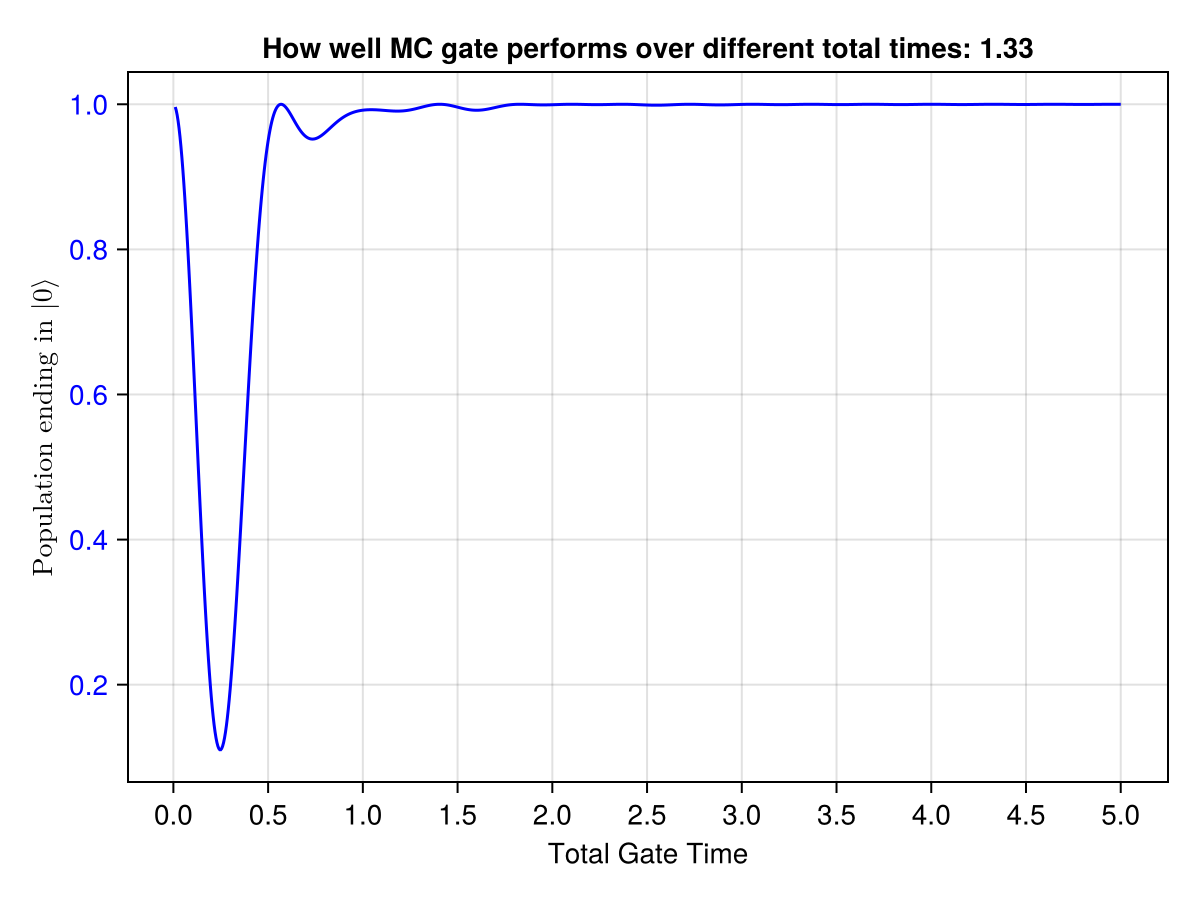

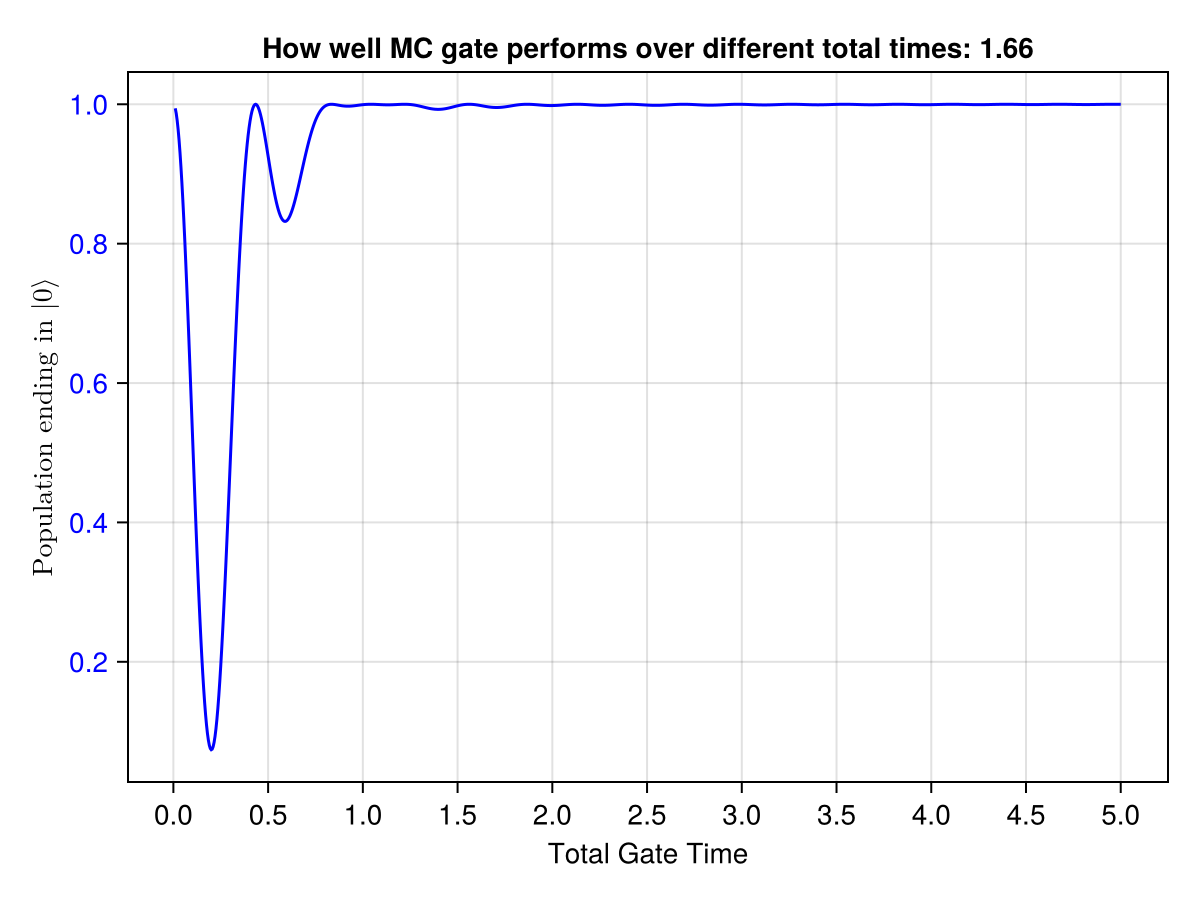

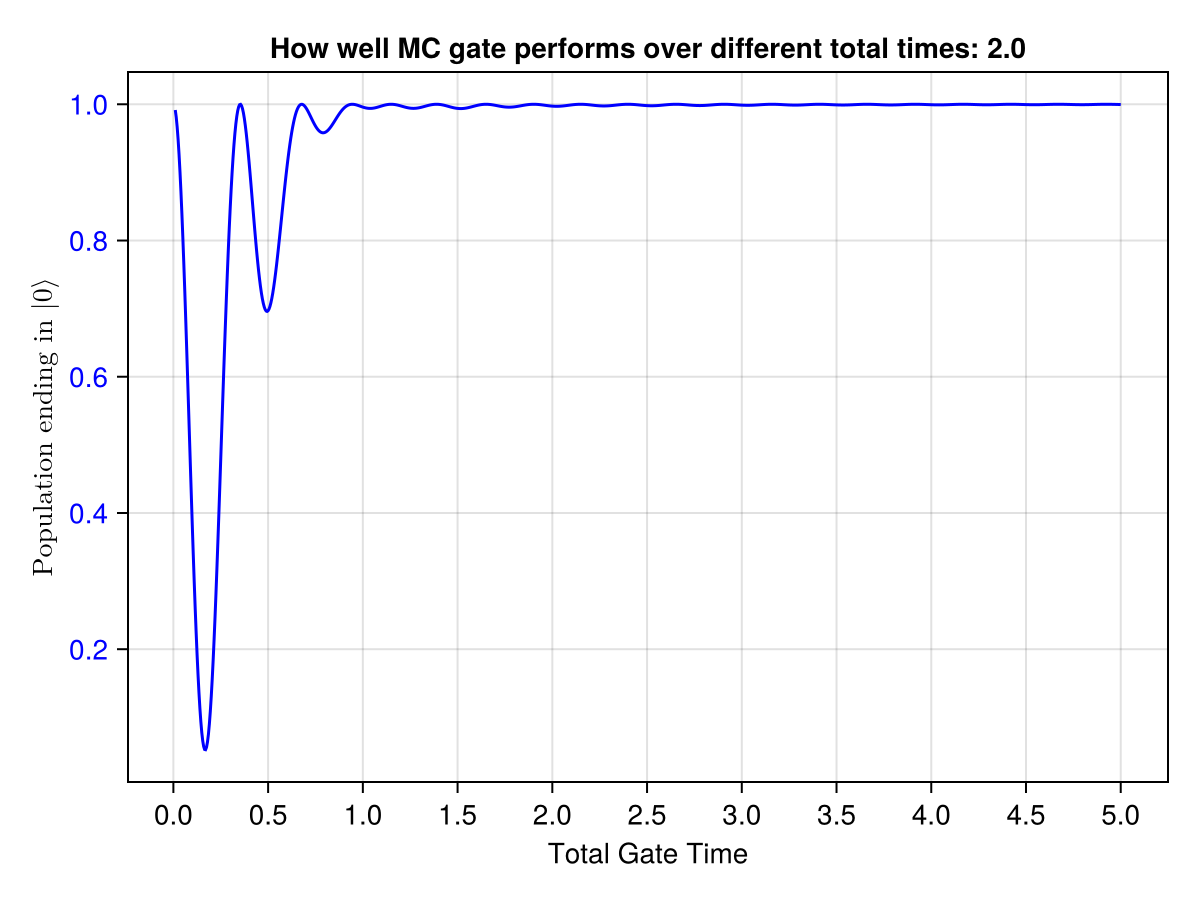

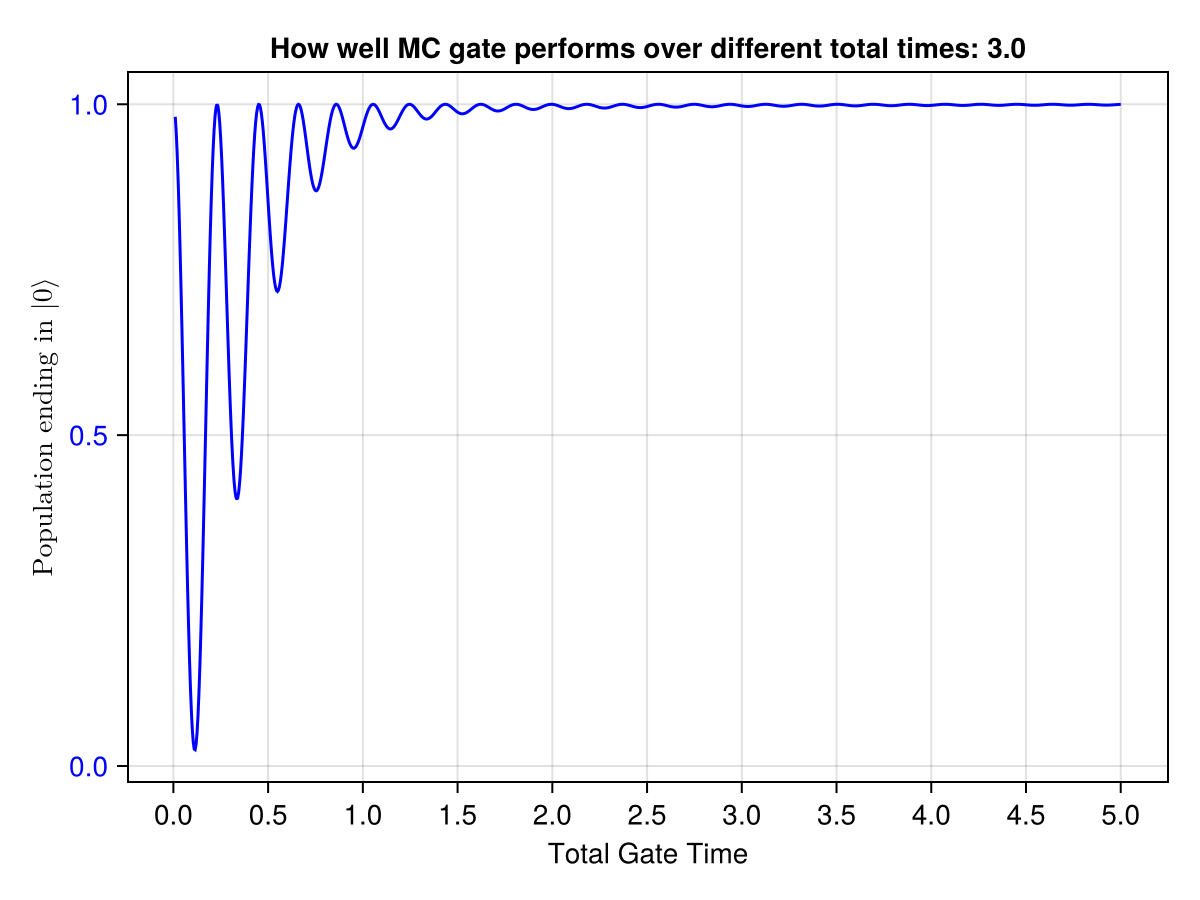

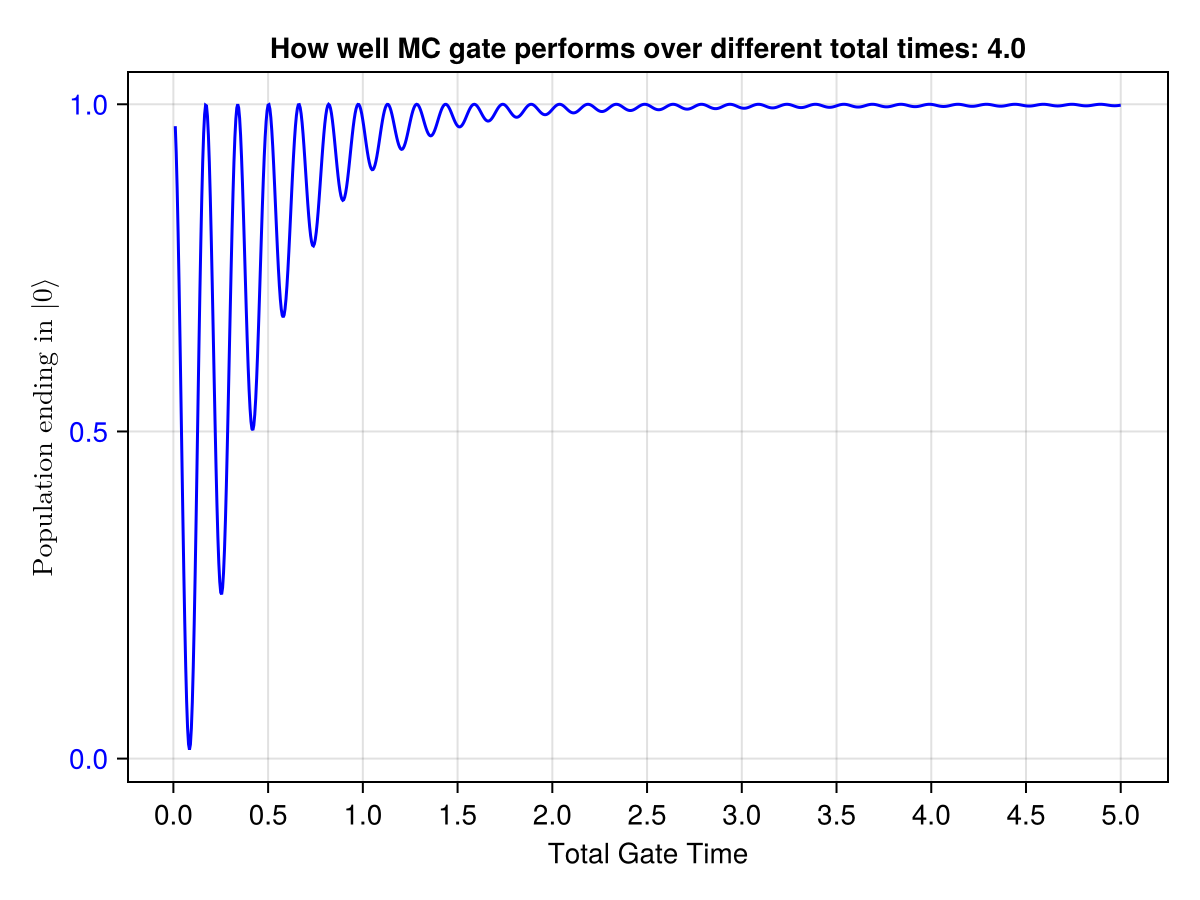

In [2]:
using QuantumOptics

iterations = 1000
tmin = 0.01
tmax = 5
Ts = range(tmin, tmax, iterations)

for strength_multiplier in [0.5, 1, 1.33, 1.66, 2, 3, 4]
    function ending_population(T::Real) 
        (tout, psi_t, H), (Δ, Ω, ϕ) = mattChow(T, strength_multiplier)
        return abs2(psi_t[end][2])
    end

    # plotting
    fig = Figure()
    ax1 = Axis(fig[1, 1], yticklabelcolor = :blue,

        title = "How well MC gate performs over different total times: $strength_multiplier",
        xlabel = "Total Gate Time",
        ylabel = L"Population ending in $|0\rangle$",
        xticks = (0:0.5:tmax)
    )

    lines!(ax1, Ts, ending_population, color = :blue)
    # lines!(ax2, Ts, x -> sin.(ending_phase(x)), color = :red)
    display(fig)
end

Now the real question is "why is this happening?"

StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}

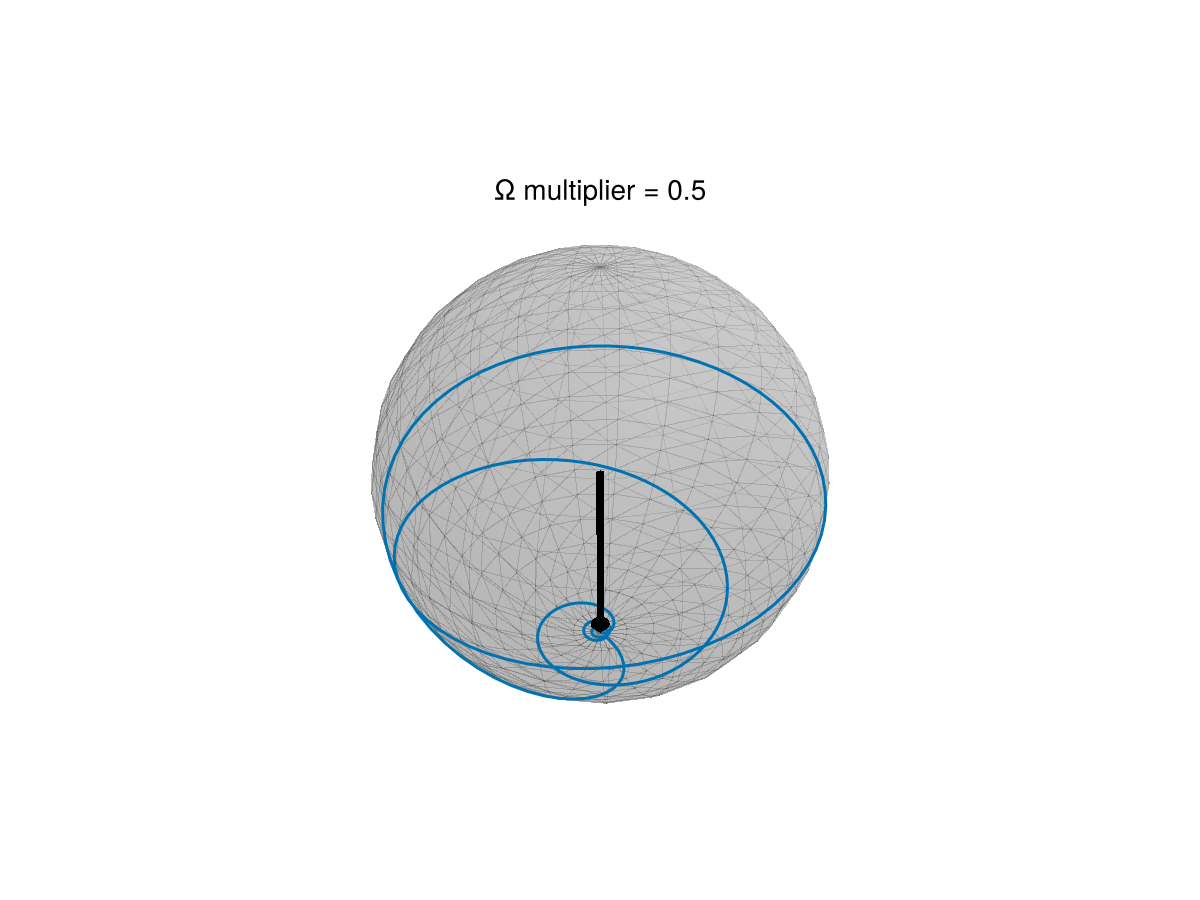

StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}

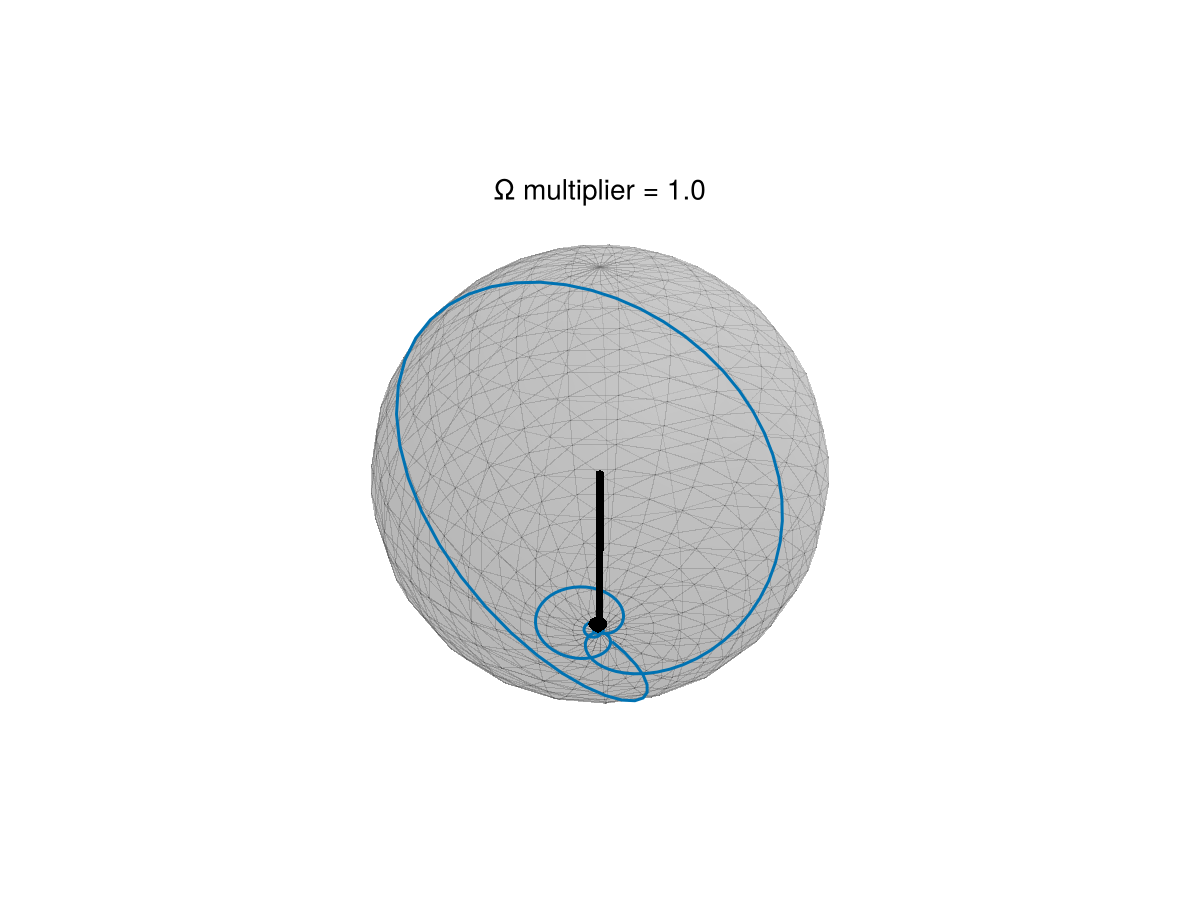

StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}

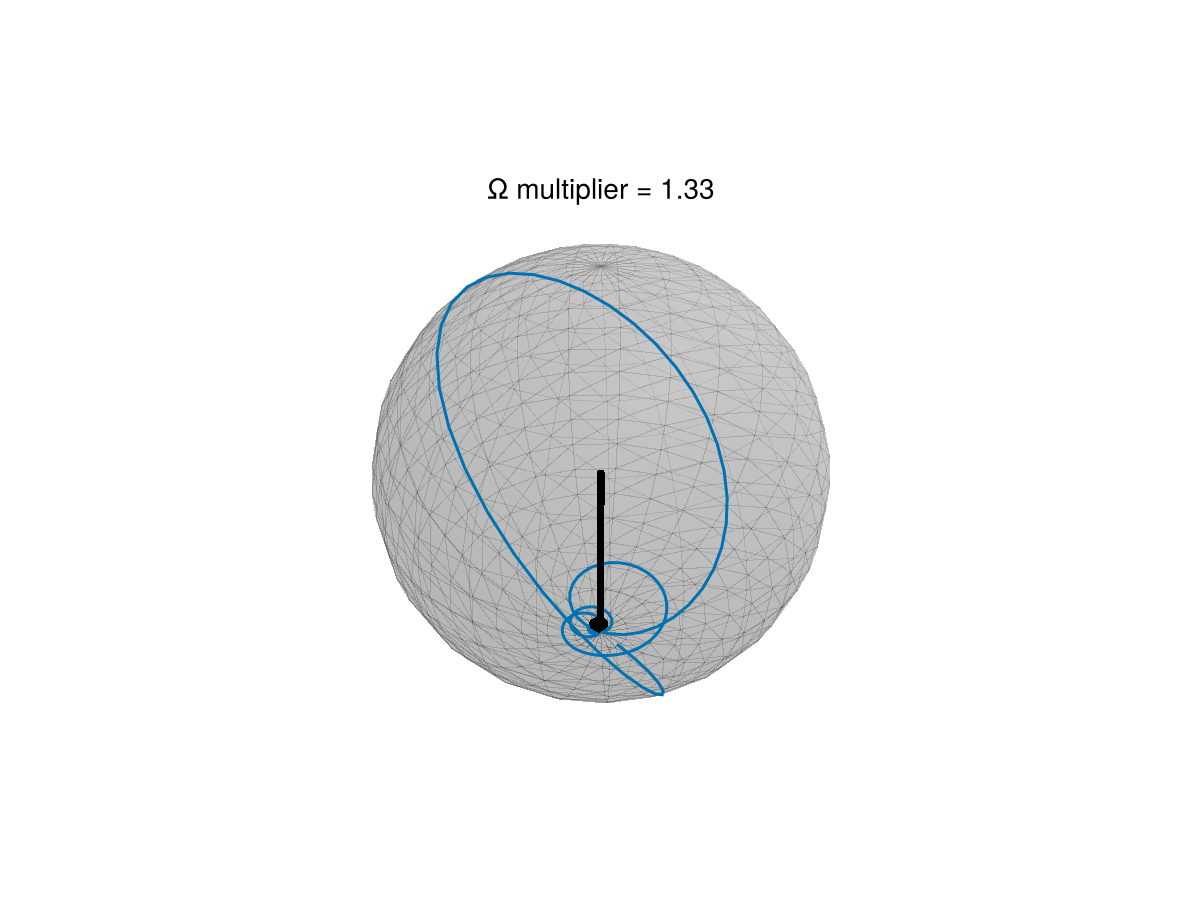

StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}

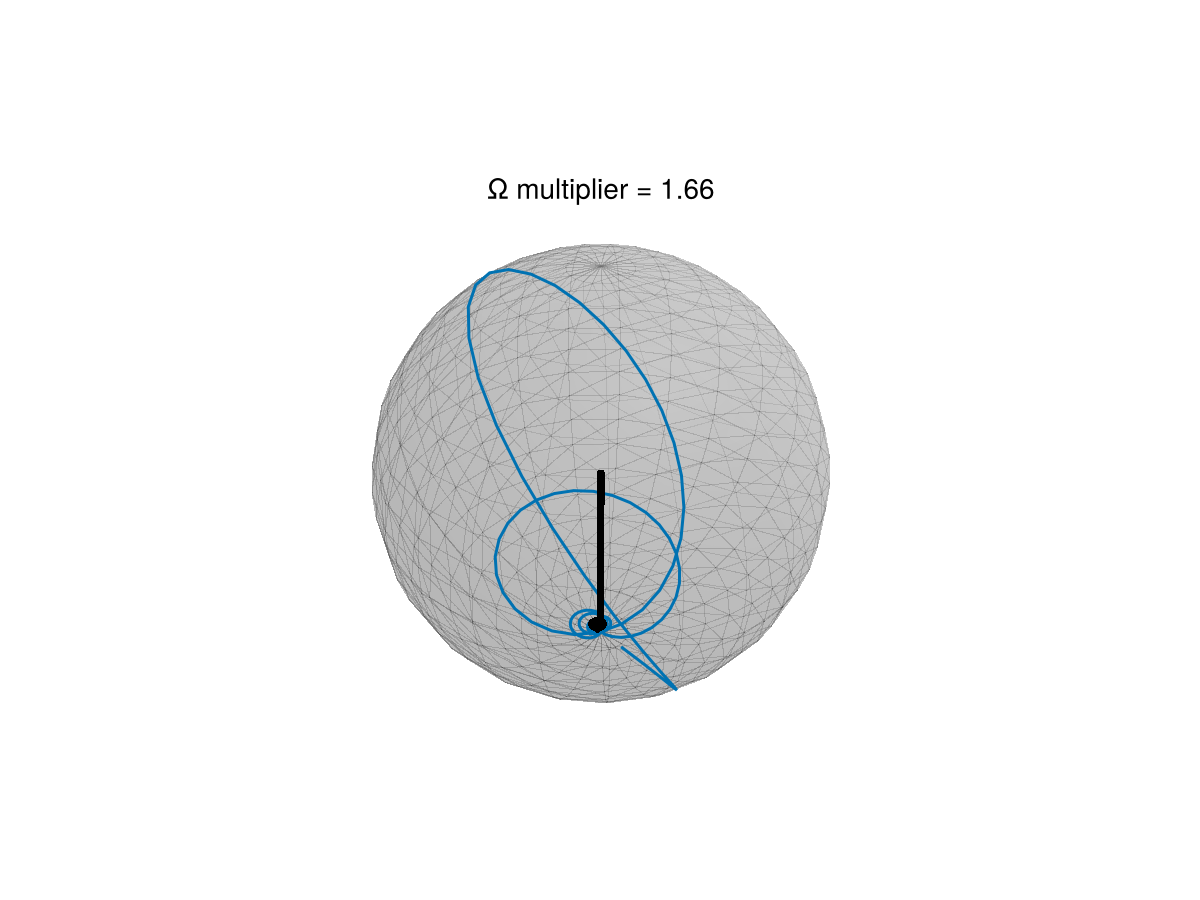

StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}

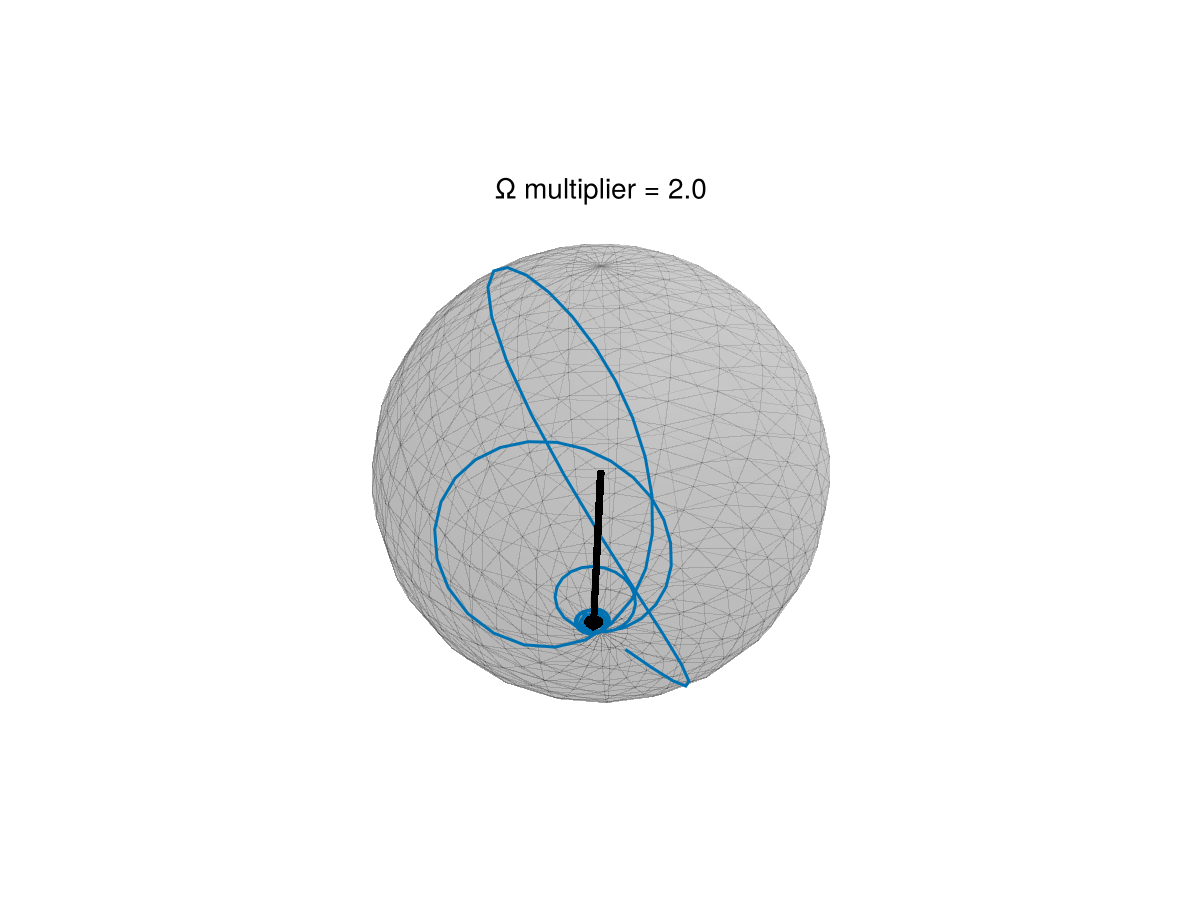

StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}

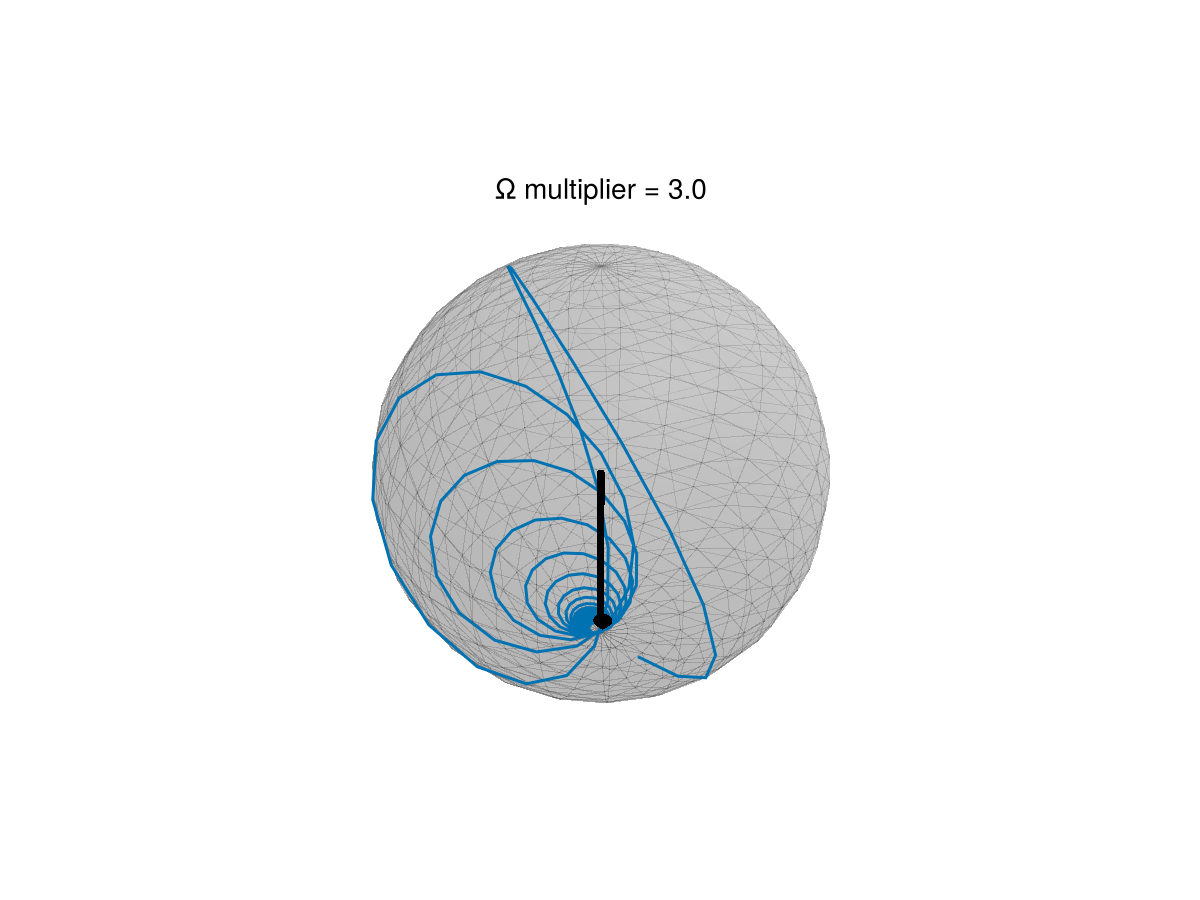

StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}

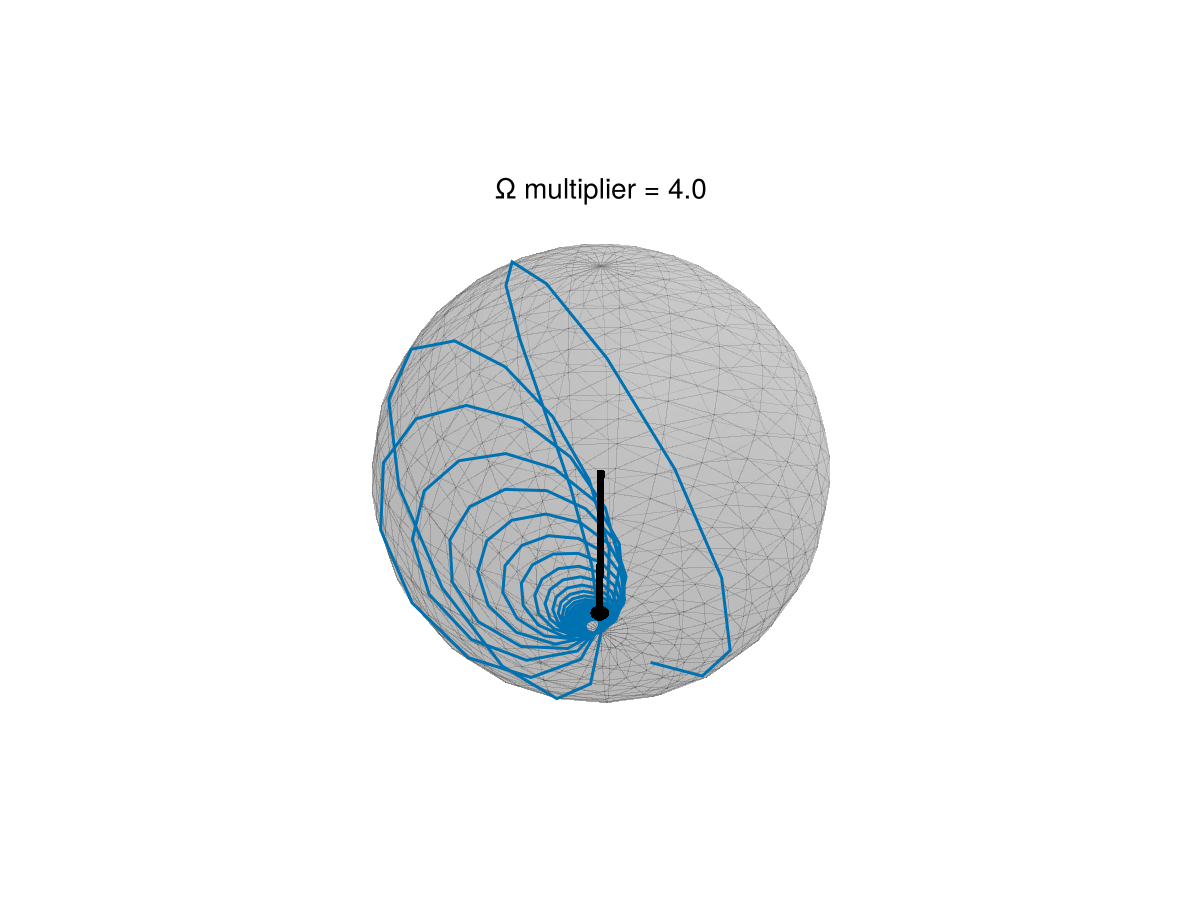

In [3]:
using QuantumOptics
include("./Plotting.jl")

iterations = 400
tmin = 0.01
tmax = 5
Ts = range(tmin, tmax, iterations)

for (i, strength_multiplier) in enumerate([0.5, 1, 1.33, 1.66, 2, 3, 4])
    function ending_population(T::Real) 
        (tout, psi_t, H), (Δ, Ω, ϕ) = mattChow(T, strength_multiplier)
        return abs2(psi_t[end][2])
    end
    function ending_state(T::Real) 
        (tout, psi_t, H), (Δ, Ω, ϕ) = mattChow(T, strength_multiplier)
        return psi_t[end]
    end

    final_states = ending_state.(Ts)

    print(typeof(Ts))
    # plotting
    
    fig = Figure()
    bloch = bloch_plot!(fig[1,1], Ts, final_states, title="Ω multiplier = $strength_multiplier")
    display(fig)

end

If we want to explore how this gate gets closer to adiabatic, we want to define *how* adiabatic it gets. 

We have two ways we have discussed quantifying how "adiabatic" a system is. I will name then $D_1$ and $D_2$ for now since I am not creative. If these quantities as low, the system should be more adiabaitic. 

$D_1$ is only dependent on the Hamiltonian and is therefore a measure of if the Hamiltonian is adiabatic on average.
$$
D_1 = \frac{1}{T} \int _0 ^T \left| \frac{\bra{\tilde0} \dot{\hat{H}} \ket{\tilde1}}{E_{\tilde0} - E_{\tilde1}} \right| dt
$$

In [11]:
function mids(ts)
    return [(x+y)/2 for (x, y) in zip(ts[1:end], ts[2:end])] 
end

function D1_of_process(H::Function, tspan::Tuple, tsteps::Int)
    T = tspan[2]
    ts_full = range(tspan[1], T, tsteps)
    ts = mids(ts_full) 
    dt = (ts[2] - ts[1])/2
    Hts = H.(ts)
    eigens_ts = eigenstates.(dense.(H.(ts)))
    hamiltonian_eigenenergies_ts = getindex.(eigens_ts, 1)
    hamiltonian_eigenkets_ts = getindex.(eigens_ts, 2)

    # get \dot{H}
    H_dot(t) = (H(t+dt/2) - H(t-dt/2))/dt
    H_dot_ts = H_dot.(ts)
    
    # get dressed states E_̃0 and E_̃1
    dressed_zeros_kets_ts = getindex.(hamiltonian_eigenkets_ts, 1)
    dressed_zeros_bras_ts = dagger.(dressed_zeros_kets_ts)
    dressed_ones_kets_ts = getindex.(hamiltonian_eigenkets_ts, 2)

    H_dot_factor_ts = dressed_zeros_bras_ts .* (H_dot_ts .* dressed_ones_kets_ts)

    # get energy difference
    dressed_zero_energy_ts = getindex.(hamiltonian_eigenenergies_ts, 1)
    dressed_one_energy_ts = getindex.(hamiltonian_eigenenergies_ts, 2)
    ΔE_ts = dressed_zero_energy_ts .- dressed_one_energy_ts

    # simple Riemann summation integration
    diabaticity_ts = abs.(H_dot_factor_ts ./ ΔE_ts)
    integral = sum(diabaticity_ts)*T/T
    return integral
end



D1_of_process (generic function with 1 method)

$D_2$ is instead a measure of how well we stay instantaneously aligned with the Rabi vector $\tilde{\vec{\Omega}}$. This we can define as:
$$
D_2 = \frac{1}{T} \int _0 ^T | \left< {\tilde0} | {\psi(t)} \right> | dt
$$

In [ ]:
function mids(ts)
    return [(x+y)/2 for (x, y) in zip(ts[1:end], ts[2:end])] 
end

function D2_of_process(H::Function, ψ_t::StateVector, tspan::Tuple, tsteps::Int)
    T = tspan[2]
    ts = range(tspan[1], T, tsteps)
    dt = (ts[2] - ts[1])/2
    Hts = H.(ts)
    eigens_ts = eigenstates.(dense.(H.(ts)))
    hamiltonian_eigenenergies_ts = getindex.(eigens_ts, 1)
    hamiltonian_eigenkets_ts = getindex.(eigens_ts, 2)

    # get \dot{H}
    H_dot(t) = (H(t+dt/2) - H(t-dt/2))/dt
    H_dot_ts = H_dot.(ts)
    
    # get dressed states E_̃0 and E_̃1
    dressed_zeros_kets_ts = getindex.(hamiltonian_eigenkets_ts, 1)
    dressed_zeros_bras_ts = dagger.(dressed_zeros_kets_ts)
    # dressed_ones_kets_ts = getindex.(hamiltonian_eigenkets_ts, 2)

    H_dot_factor_ts = dressed_zeros_bras_ts .* (H_dot_ts .* dressed_ones_kets_ts)

    # get energy difference
    dressed_zero_energy_ts = getindex.(hamiltonian_eigenenergies_ts, 1)
    dressed_one_energy_ts = getindex.(hamiltonian_eigenenergies_ts, 2)
    ΔE_ts = dressed_zero_energy_ts .- dressed_one_energy_ts

    # simple Riemann summation integration
    diabaticity_ts = abs.(inner)
    integral = sum(diabaticity_ts)*T/T
    return integral
end

Now we check these against the "return to ground state" performance.

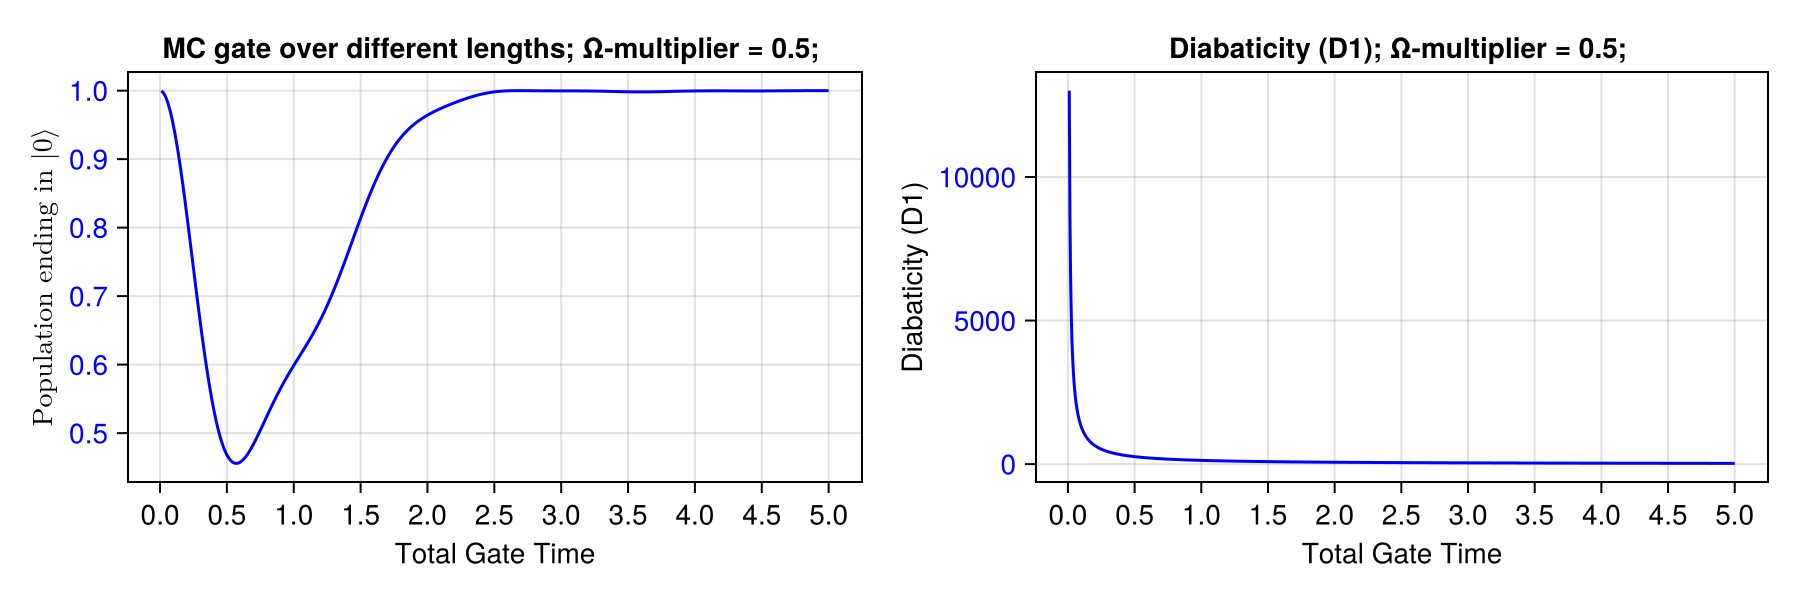

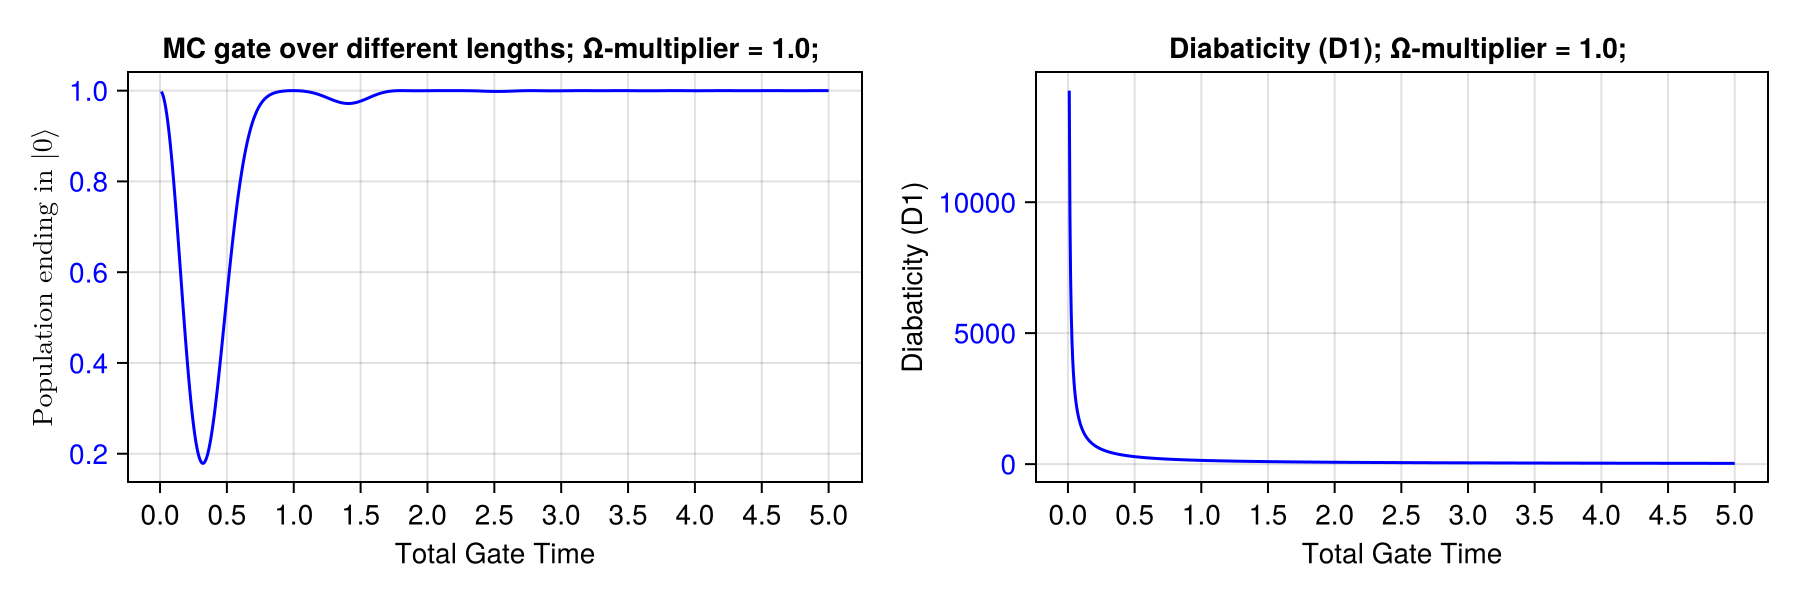

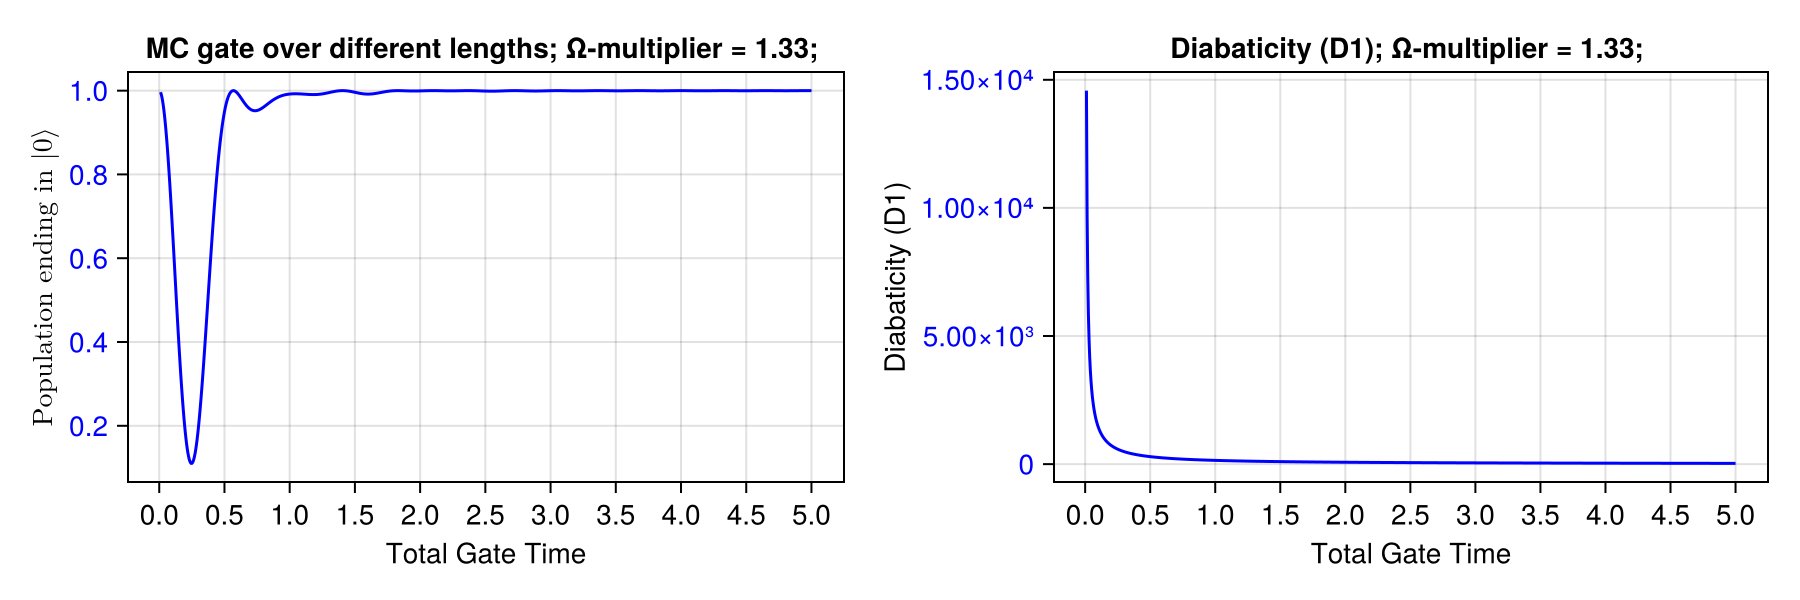

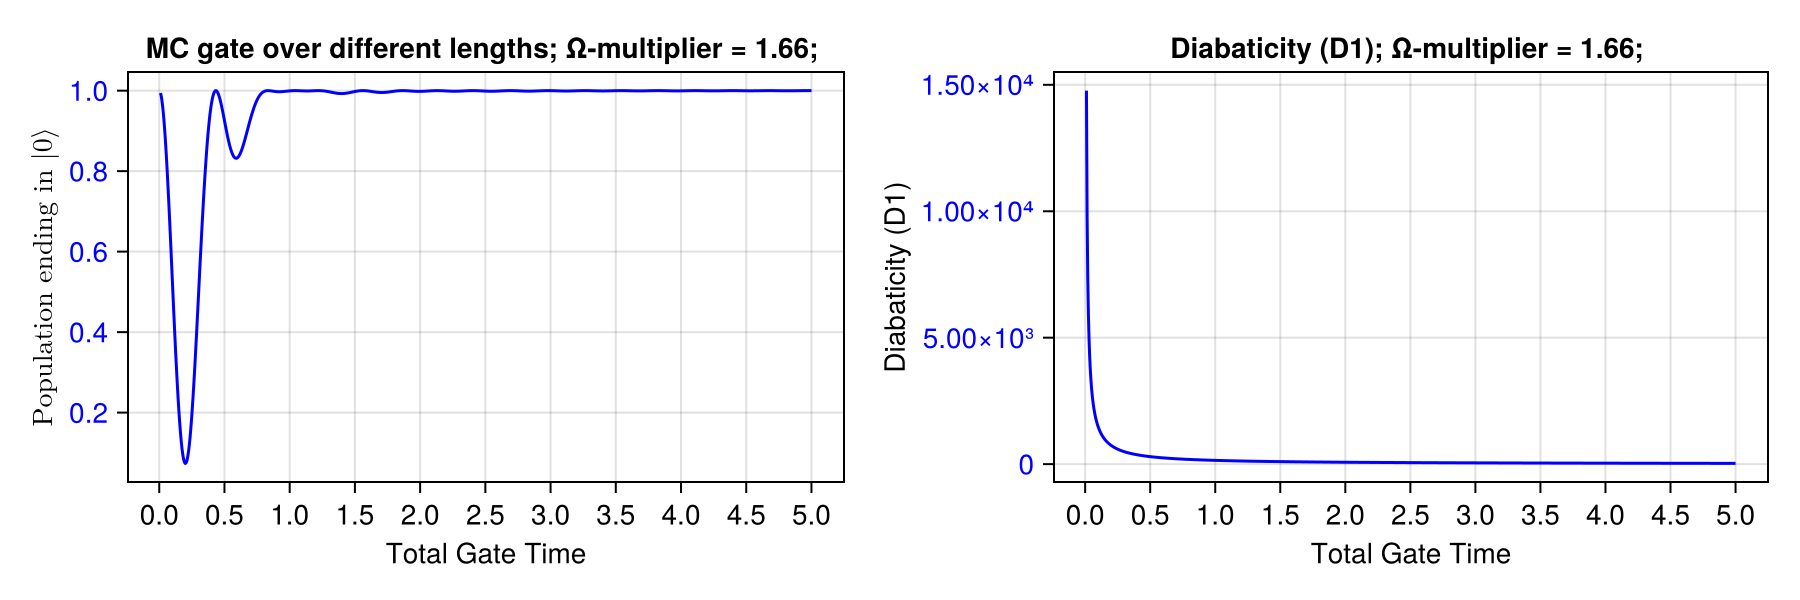

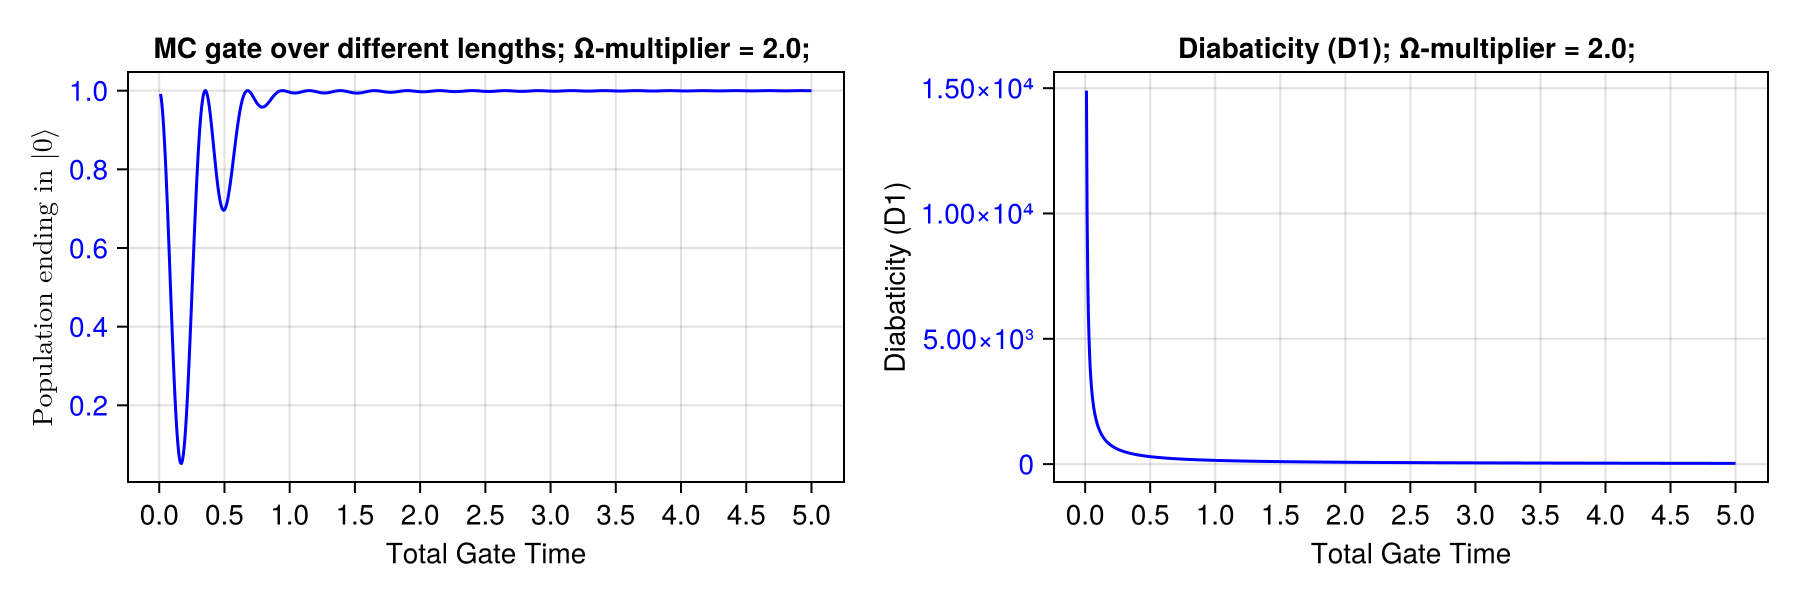

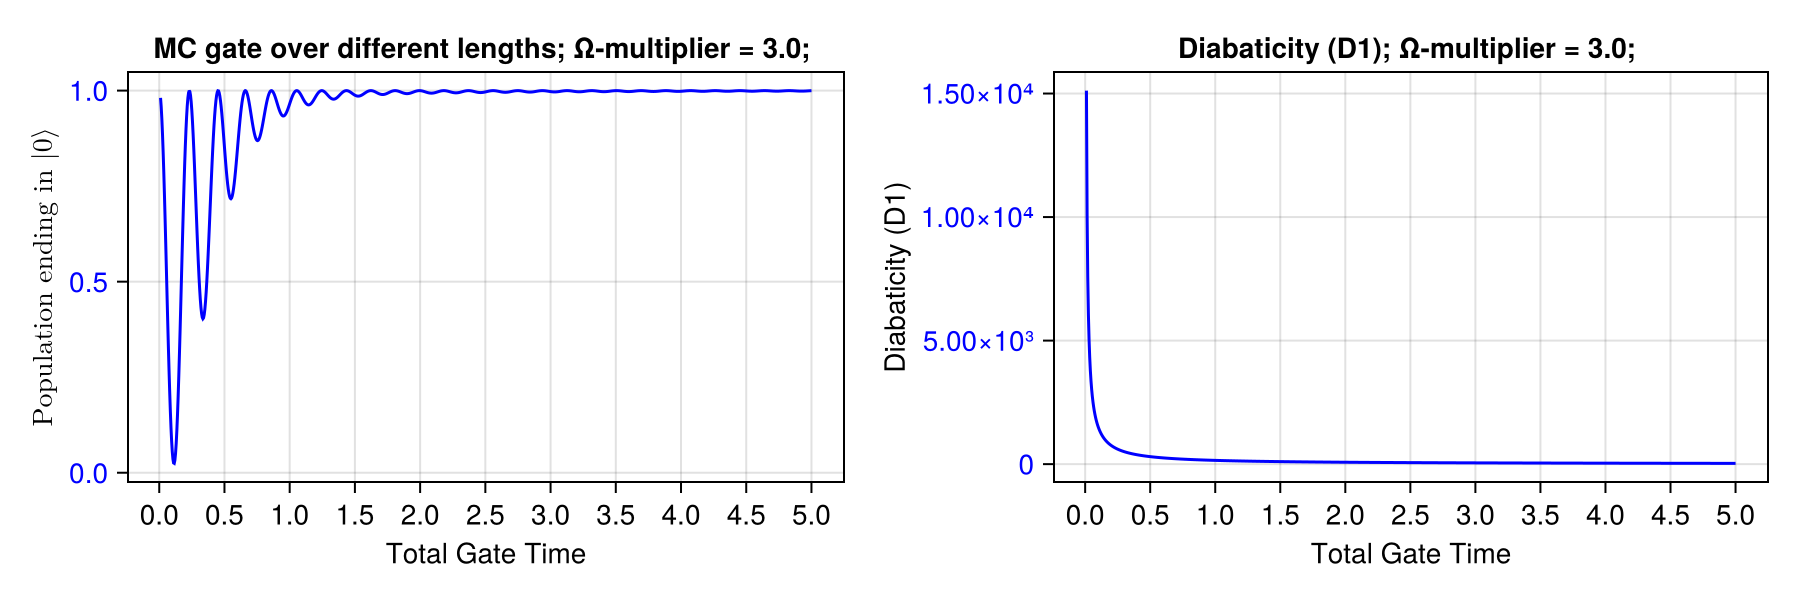

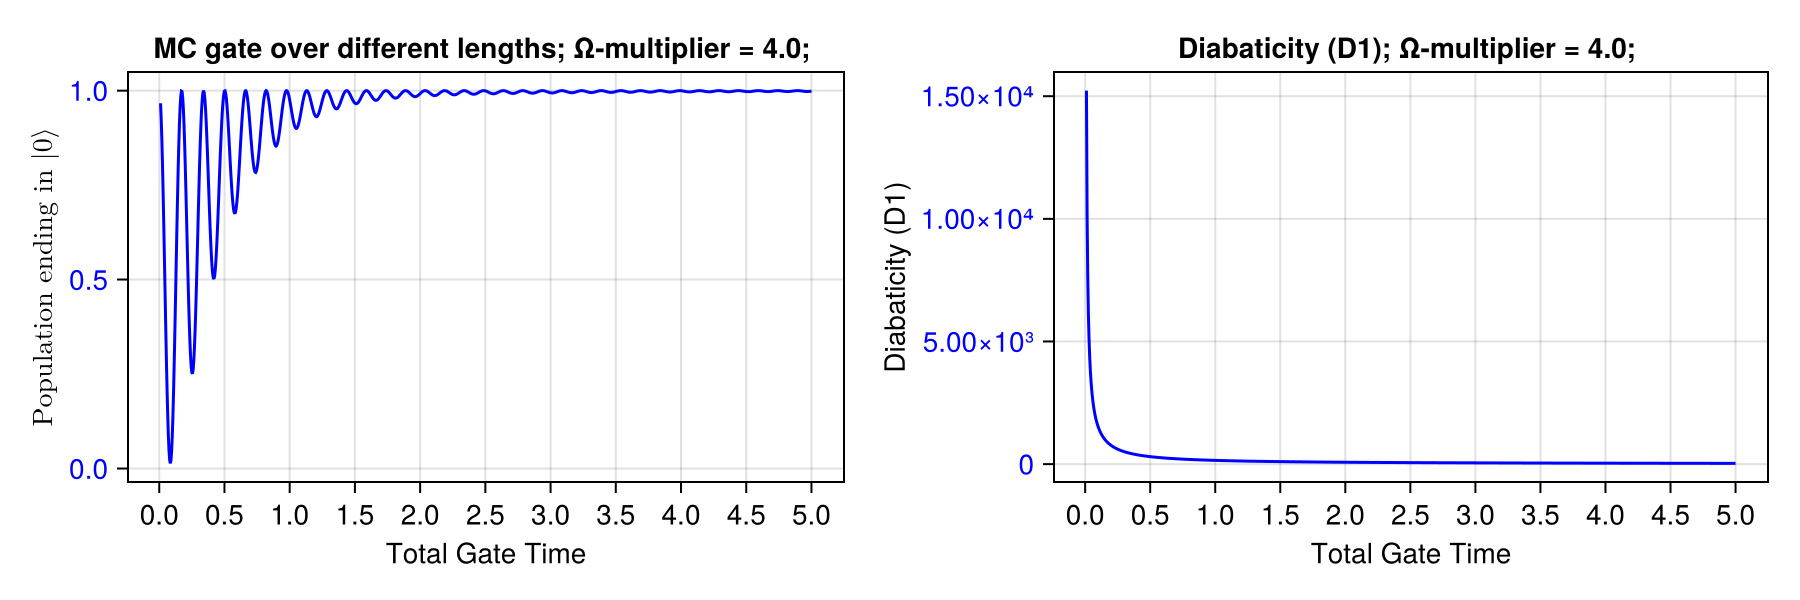

In [17]:
using QuantumOptics

iterations = 1000
tmin = 0.01
tmax = 5
Ts = range(tmin, tmax, iterations)

for strength_multiplier in [0.5, 1, 1.33, 1.66, 2, 3, 4]
    function ending_population(T::Real) 
        (tout, psi_t, H), (Δ, Ω, ϕ) = mattChow(T, strength_multiplier)
        return abs2(psi_t[end][2])
    end
    function D1_for_mc(T::Real)
        (tout, psi_t, H), (Δ, Ω, ϕ) = mattChow(T, strength_multiplier)
        return D1_of_process(H, (0, T), 100)
    end

    # plotting
    fig = Figure(size = (300*3, 300))
    ax1 = Axis(fig[1, 1], yticklabelcolor = :blue,

        title = "MC gate over different lengths; Ω-multiplier = $strength_multiplier; ",
        xlabel = "Total Gate Time",
        ylabel = L"Population ending in $|0\rangle$",
        xticks = (0:0.5:tmax)
    )
    lines!(ax1, Ts, ending_population, color = :blue)

    ax2 = Axis(fig[1, 2], yticklabelcolor = :blue,

        title = "Diabaticity (D1); Ω-multiplier = $(strength_multiplier); ",
        xlabel = "Total Gate Time",
        ylabel = "Diabaticity (D1)",
        xticks = (0:0.5:tmax)
    )
    lines!(ax2, Ts, D1_for_mc, color = :blue)
    # lines!(ax2, Ts, x -> sin.(ending_phase(x)), color = :red)
    display(fig)
end